#Лабораторная работа №5

# Задание



Для набора данных с помощью автоэнкодера получить эмбеддинг изображений и его визуализировать.

Загрузить собственную аудиозапись и использовать автоэнкодер для удаления шума из аудиозаписи.

Отчет должен содержать: титульный лист, задание с вариантом, скриншоты и краткие пояснения по каждому этапу лабораторной работы, результаты эмбеддинга изображения, результаты удаления шума из аудиозаписи, итоговую таблицу со результатами для всех вариантов обучения

# Задания для самостоятельной работы
1. Проведите обучение модели по вашему варианту.
2. Измените гиперпараметры обучения для понижения ошибки модели: количество эпох, размер батча, скорость обучения,
3. Измените количество слоев/нейронов, чтобы уменьшить и увеличить размерность скрытого пространства. Сравните полученные результаты
4. Обучите модель автоэнкодера для удаления шума из аудио.
5. Измените гиперпараметры обучения для улучшения коэффициента детерминации: количество эпох, размер батча, скорость обучения
6. Измените количество каналов, чтобы уменьшить и увеличить размерность скрытого пространства. Сравните полученные результаты
7. Укажите, какие действия помогли улучшить метрики ваших моделей и объясните почему.

# Контрольные вопросы
1. Архитектура автоэнкодера. Варианты, применение
2. Что такое эмбеддинг. Что такое Метод главных компонент? Где применяется?
3. Форматы аудиофайлов, отличия. Формат представления аудио для нейросети.
4. Что такое коэффициент детерминации? Практический смысл, применение.
5. Функция потерь mse и оптимизатор adam.
6. Как работает транспонированный сверточный слой?
7. Функции активации: гиперболический тангенс и ELU.
8. Как устроен GAN?
9. Как устроен VAE?

## Часть 1. Автоэнкодер для визуализации данных

In [ ]:
import pickle
from scipy import signal
from scipy.io import wavfile
import numpy as np
from IPython.display import display, Audio
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import Dataset, TensorDataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from IPython.display import clear_output
from ipywidgets import interact
from PIL import Image
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
!tar -xvzf cifar-100-python.tar.gz

--2026-04-12 23:59:40--  https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 169001437 (161M) [application/x-gzip]
Saving to: ‘cifar-100-python.tar.gz’

cifar-100-python.ta 100%[===================>] 161.17M  14.2MB/s    in 13s     

2026-04-12 23:59:54 (12.5 MB/s) - ‘cifar-100-python.tar.gz’ saved [169001437/169001437]

cifar-100-python/
cifar-100-python/file.txt~
cifar-100-python/train
cifar-100-python/test
cifar-100-python/meta


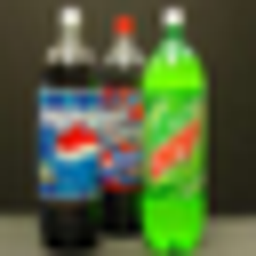

In [ ]:
with open('cifar-100-python/train', 'rb') as f:
    data_train = pickle.load(f, encoding='latin1')
with open('cifar-100-python/test', 'rb') as f:
    data_test = pickle.load(f, encoding='latin1')

# Здесь указать ваши классы по варианту!!!
CLASSES = [9, 38, 58]

train_X = data_train['data'].reshape(-1, 3, 32, 32)
train_X = np.transpose(train_X, [0, 2, 3, 1]) # NCHW -> NHWC
train_y = np.array(data_train['fine_labels'])
mask = np.isin(train_y, CLASSES)
train_X = train_X[mask].copy()
train_y = train_y[mask].copy()
train_y = np.unique(train_y, return_inverse=1)[1]
del data_train

test_X = data_test['data'].reshape(-1, 3, 32, 32)
test_X = np.transpose(test_X, [0, 2, 3, 1])
test_y = np.array(data_test['fine_labels'])
mask = np.isin(test_y, CLASSES)
test_X = test_X[mask].copy()
test_y = test_y[mask].copy()
test_y = np.unique(test_y, return_inverse=1)[1]
del data_test
Image.fromarray(train_X[50]).resize((256,256))

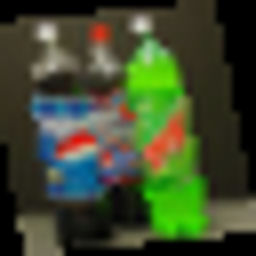

In [ ]:
class CifarDataset(Dataset):
     def __init__(self, X, y, transform=None, p=0.0):
         assert X.size(0) == y.size(0)
         super(Dataset, self).__init__()
         self.X = X
         self.y = y
         self.transform = transform
         self.prob = p

     def __len__(self):
         return self.y.size(0)

     def __getitem__(self, index):
        x = self.X[index]
        if self.transform and np.random.random()<self.prob:
            x = self.transform(x.permute(2, 0, 1)/255.).permute(1, 2, 0)*255.
        y = self.y[index]
        return x, y

transform = T.Compose([
     T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.0),
     T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2),
                    shear=5),
])

Image.fromarray((transform(torch.Tensor(train_X[50]).permute(2, 0, 1)/255.).\
                 permute(1, 2, 0).numpy()*255.).astype(np.uint8)).\
                 resize((256, 256))

In [ ]:
batch_size = 128
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES))/1.
    dataset = CifarDataset(tensor_x, tensor_y,
                           transform if part=='train' else None,
                           p=0.5) # создание объекта датасета
    dataloader[part] = DataLoader(dataset, batch_size=batch_size,
                                  prefetch_factor=8 if part=='train' else 2,
                                  num_workers=2, persistent_workers=True,
                                  shuffle=True) # создание экземпляра класса DataLoader
dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7f790bde13a0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7f77a496ad20>}

In [ ]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.mean = torch.tensor(mean).to(device)
        self.std = torch.tensor(std).to(device)

    def forward(self, input):
        x = input / 255.0
        x = x - self.mean
        x = x / self.std
        #x = torch.mean(x, axis=-1)
        return torch.flatten(x, start_dim=1) # nhw -> nm

class Cifar100_AE(nn.Module):
    def __init__(self, hidden_size=32, classes=100):
        super(Cifar100_AE, self).__init__()
        # https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1
        self.norm = Normalize([0.5074,0.4867,0.4411],[0.2011,0.1987,0.2025])
        self.encoder = nn.Sequential(
            nn.Linear(32*32*3, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, hidden_size//2),
            # nn.ELU(),
            # nn.Linear(hidden_size//2, hidden_size//8),
            # nn.ELU(),
            # nn.Linear(hidden_size//8, hidden_size//16),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            # nn.Linear(hidden_size//16, hidden_size//8),
            # nn.ELU(),
            # nn.Linear(hidden_size//8, hidden_size//2),
            # nn.ELU(),
            nn.Linear(hidden_size//2, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, 32*32*3),
        )

    def forward(self, input):
        normed = self.norm(input)
        encoded = self.encoder(normed)
        out = self.decoder(encoded)
        return out, encoded, normed

HIDDEN_SIZE = 1024
model = Cifar100_AE(hidden_size=HIDDEN_SIZE, classes=len(CLASSES))
model.to(device)

Cifar100_AE(
  (norm): Normalize()
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): Tanh()
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=1024, out_features=3072, bias=True)
  )
)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

  0%|          | 0/2400 [00:00<?, ?it/s]

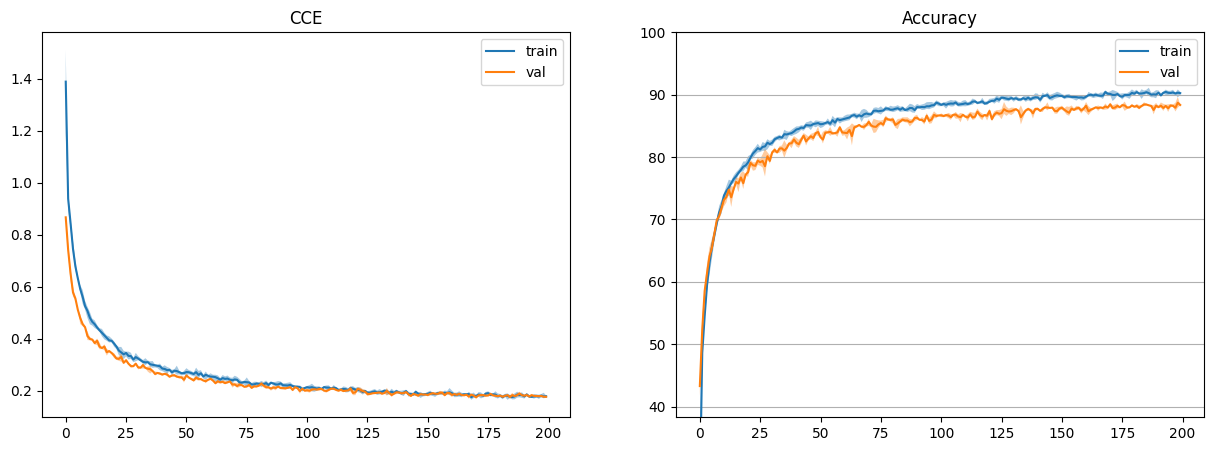

Обучение закончено за 167.30652594566345 секунд

ИТОГОВЫЕ РЕЗУЛЬТАТЫ:
Точность на обучающей выборке: 90.25%
Точность на тестовой выборке:   88.35%

Лучшая точность на обучающей выборке: 90.44%
Лучшая точность на тестовой выборке:   88.71%


In [ ]:
EPOCHS = 200
REDRAW_EVERY = 20
steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])
# NEW
pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0
for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    #running_loss = 0.0
    tmp = []
    model.train()
    for i, batch in enumerate(dataloader['train'], 0):
        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, _ = batch
        # на GPU
        inputs, _ = inputs.to(device), _.to(device)

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        outputs = model(inputs)
        loss = criterion(outputs[0], outputs[2])
        loss.backward()
        optimizer.step()

        # для подсчёта статистик
        accuracy = r2_score(outputs[2].detach().cpu().numpy(),
                            outputs[0].detach().cpu().numpy())*100
        tmp.append((loss.item(), accuracy))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    tmp = []
    model.eval()
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, _ = data
            # на GPU
            inputs, _ = inputs.to(device), _.to(device)

            outputs = model(inputs)
            loss = criterion(outputs[0], outputs[2])
            accuracy = r2_score(outputs[2].detach().cpu().numpy(),
                            outputs[0].detach().cpu().numpy())*100
            tmp.append((loss.item(), accuracy))
    #print(f'[{epoch + 1}, {i + 1:5d}] val loss: {running_loss / steps_per_epoch_val:.3f}')
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    if (epoch+1) % REDRAW_EVERY != 0:
        continue
    clear_output(wait=False)
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS*steps_per_epoch, miniters=5)
    pbar.update((epoch+1)*steps_per_epoch)
    x_vals = np.arange(epoch+1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)
    ax[1].set_ylim(stats_val[:, 0, 1].min()-5, 100)
    ax[1].grid(axis='y')
    for i, title in enumerate(['CCE', 'Accuracy']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i],
                           stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals,
                           stats_val[:, 1, i],
                           stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
    plt.show()

# Добавленный код для вывода итогового accuracy
print('Обучение закончено за %s секунд' % passed)

# Получение финальных метрик
final_train_accuracy = losses[-1][0][1]  # последнее значение accuracy для train
final_val_accuracy = losses_val[-1][0][1]  # последнее значение accuracy для val

# Вывод с форматированием
print('\n' + '='*50)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ:')
print('='*50)
print(f'Точность на обучающей выборке: {final_train_accuracy:.2f}%')
print(f'Точность на тестовой выборке:   {final_val_accuracy:.2f}%')
print('='*50)

# Дополнительно можно вывести лучшие результаты за всё обучение
best_train_acc = max([loss[0][1] for loss in losses])
best_val_acc = max([loss[0][1] for loss in losses_val])
print(f'\nЛучшая точность на обучающей выборке: {best_train_acc:.2f}%')
print(f'Лучшая точность на тестовой выборке:   {best_val_acc:.2f}%')

### Получение результатов обученной модели

In [ ]:
embeddings = []
colors = []
images = []
reconstructs = []
model.eval()
with torch.no_grad():
    for i, batch in enumerate(dataloader['test'], 0):
        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, labels = batch
        # на GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        out, embedding, norm = model(inputs)
        embeddings.append(embedding.detach().cpu().numpy())
        images.append(inputs.detach().cpu().numpy())
        reconstructs.append(out.detach().cpu().numpy())
        colors.append(labels.argmax(-1).detach().cpu().numpy())
embeddings = np.concatenate(embeddings, axis=0)
images = np.concatenate(images, axis=0)
reconstructs = np.concatenate(reconstructs, axis=0)
reconstructs = (reconstructs-reconstructs.min())/(reconstructs.max()-reconstructs.min())
colors = np.concatenate(colors, axis=0)

### Визуализация восстановленной картинки

In [ ]:
def draw_comparision(index=0):
   fig, ax = plt.subplots(1, 2, figsize=(10, 5))
   ax[0].imshow(images[index].reshape(32,32,3)/255.)
   ax[1].imshow(reconstructs[index].reshape(32,32,3))
   ax[0].set_title('Оригинал')
   ax[1].set_title('Восстановленное изображение')

interact(draw_comparision, index=(0, len(images)))

interactive(children=(IntSlider(value=0, description='index', max=300), Output()), _dom_classes=('widget-inter…

<function __main__.draw_comparision(index=0)>

### Визуализация эмбеддинга

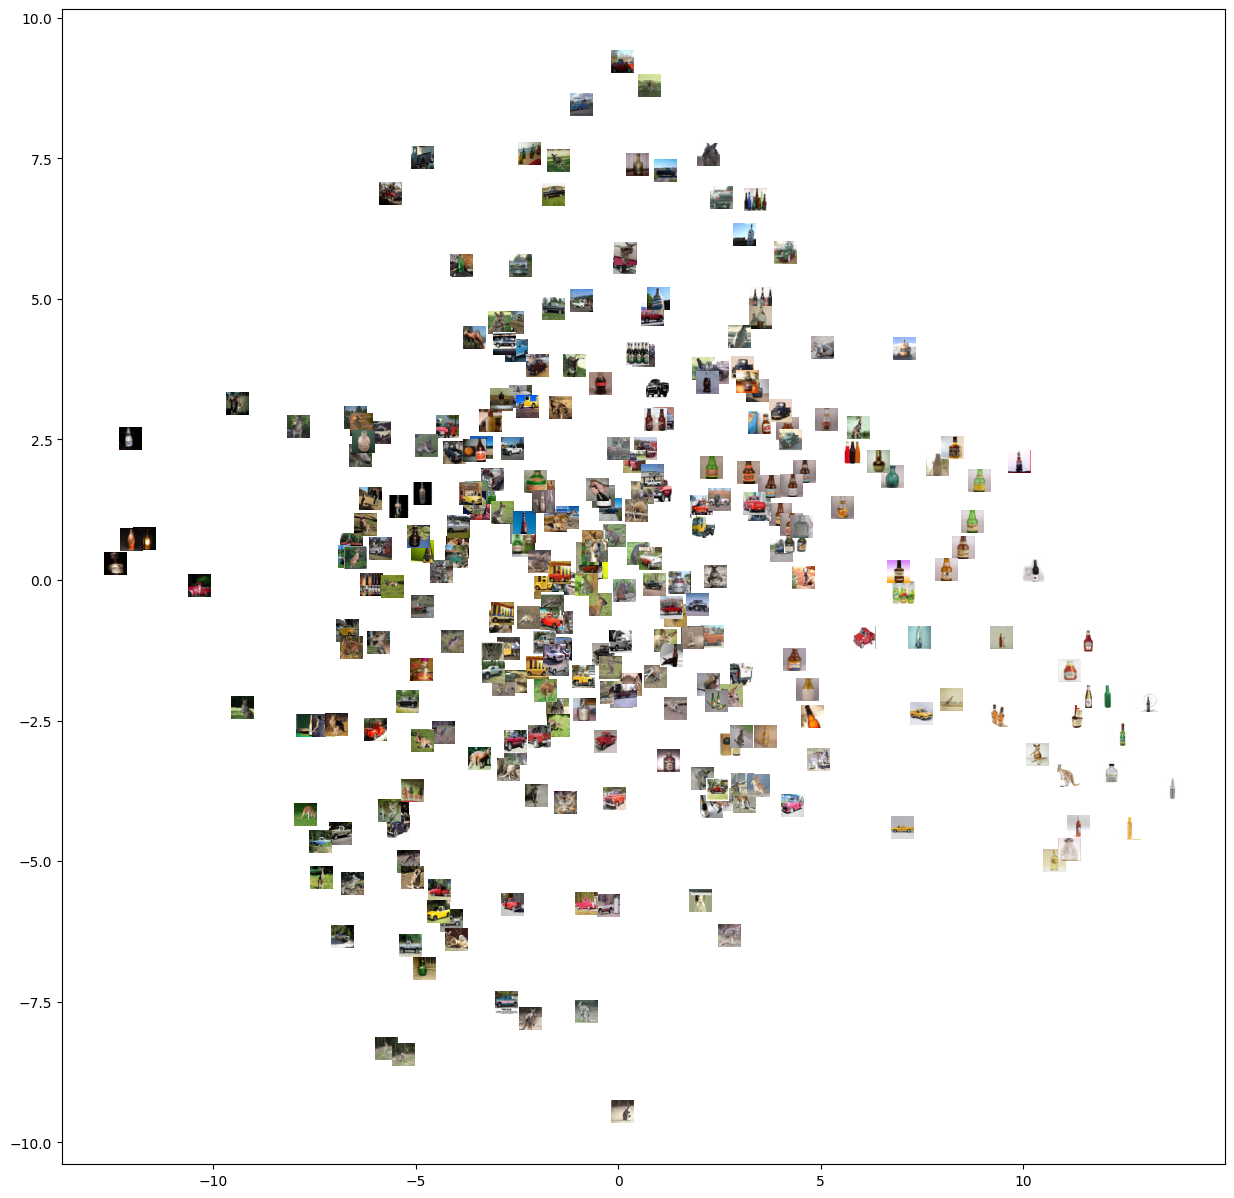

In [ ]:
# Тут мы применяем уменьшение размерности к многомерному
# эмбеддингу, полученному из бутылочного горлышка автоэнкодера.
# Можете попробовать сделать число нейронов равное 2
# и тогда данный этап можно пропустить и написать просто:
# projection = embeddings
projections = PCA(n_components=2).fit_transform(embeddings)

def implot(x, y, image, ax, zoom=1):
    im = OffsetImage(image, zoom=zoom)
    ab = AnnotationBbox(im, (x, y), xycoords='data', frameon=False)
    ax.add_artist(ab)
    ax.update_datalim(np.column_stack([x, y]))
    ax.autoscale()

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
for img, x in zip(images, projections):
    img = img.reshape(32, 32, 3)/255.
    implot(x[0], x[1], img, ax=ax, zoom=0.5)

## Часть 2. Очистка звука

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1j5TXxdWw3Se9S-v-pniXafqeJaB_IUuM?usp=sharing

In [ ]:
# загрузка мелодии
# !gdown --id 1Qta3KA-vYwMYN14FVdXXRvaRHwS_yJle
# загрузка шумов
# конвертация в wav файл с одним каналом и частотой дискретизации 16кГц
!ffmpeg -y -i voice.m4a -ac 1 -ar 16000 audio.wav
!ffmpeg -y -i noise_samples/rain.mp3 -ac 1 -ar 16000 noise.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# считывание аудио файла
fs, data = wavfile.read('audio.wav')
data = data / (2**16-1)
data[0] = 1
# добавление шума
#noise = np.random.normal(scale=0.25*data.std(), size=data.shape)
_, noise = wavfile.read('noise.wav')
noise = noise / (2**16-1)
noise = np.tile(noise, 1+data.size//noise.size)[:data.size].copy()
noise = (0.1*data.max()/noise.max())*noise
data_noised = data+noise#np.clip(data + noise, -1, 1)

In [ ]:
print('Original')
display(Audio(data[fs*0:fs*15], rate=fs))
print('Noised')
display(Audio(data_noised[fs*0:fs*15], rate=fs))

Original


Noised


In [ ]:
_, _, Zxx = signal.stft(data_noised, fs=fs, nperseg=512)
_, xrec = signal.istft(Zxx, fs)
print('Reconstructed Noised')
display(Audio(xrec[fs*0:fs*15], rate=fs))
_, _, Zxx0 = signal.stft(noise, fs=fs, nperseg=512)
_, xrec = signal.istft(Zxx0, fs)
print('Noise')
display(Audio(xrec[fs*0:fs*15], rate=fs))

Reconstructed Noised


Noise


In [ ]:
# https://github.com/digantamisra98/Mish
class Mish(nn.Module):
    def __init__(self):
        super().__init__()
        self.softplus = nn.Softplus()
        self.tanh = nn.Tanh()

    def forward(self, x):
        return x*self.tanh(self.softplus(x))

class DenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Вариант 6.6: скрытое = 256 (оригинал 1024 × 0.25 = 256)
        # self.encoder = nn.Sequential(
        #     nn.Conv1d(2, 64, kernel_size=3, stride=2, padding=1),     # 256 × 0.25 = 64
        #     Mish(),
        #     nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),   # 512 × 0.25 = 128
        #     Mish(),
        #     nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),  # 1024 × 0.25 = 256
        #     Mish(),
        # )
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose1d(256, 128, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(128, 64, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(64, 2, kernel_size=3, stride=2, padding=1),
        # )

        # Вариант 6.5: скрытое = 1536 (оригинал 1024 × 1.5)
        # self.encoder = nn.Sequential(
        #     nn.Conv1d(2, 384, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(384, 768, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(768, 1536, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        # )
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose1d(1536, 768, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(768, 384, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(384, 2, kernel_size=3, stride=2, padding=1),
        # )

        # Вариант 6.3: скрытое = 256 (в 4 раза меньше оригинала)
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, stride=2, padding=1),
            Mish(),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            Mish(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),  # ← 256
            Mish(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=3, stride=2, padding=1),
            Mish(),
            nn.ConvTranspose1d(128, 64, kernel_size=3, stride=2, padding=1),
            Mish(),
            nn.ConvTranspose1d(64, 2, kernel_size=3, stride=2, padding=1),
        )

        # Вариант 6.2: Увеличиваю. скрытое = 2048
        # self.encoder = nn.Sequential(
        #     nn.Conv1d(2, 512, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(512, 1024, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(1024, 2048, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        # )
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose1d(2048, 1024, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(1024, 512, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(512, 2, kernel_size=3, stride=2, padding=1),
        # )

        # Вариант 6.1: Уменьшаю. скрытое = 512
        # self.encoder = nn.Sequential(
        #     nn.Conv1d(2, 128, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        # )
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose1d(512, 256, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(256, 128, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(128, 2, kernel_size=3, stride=2, padding=1),
        # )

        # Старт лабы:
        # self.encoder = nn.Sequential(
        #     nn.Conv1d(2, 256, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.Conv1d(512, 1024, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        # )
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose1d(1024, 512, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(512, 256, kernel_size=3, stride=2, padding=1),
        #     Mish(),
        #     nn.ConvTranspose1d(256, 2, kernel_size=3, stride=2, padding=1),
        # )


    def forward(self, x):
        encoded = self.encoder(x)
        return self.decoder(encoded)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = DenoisingAE()
net.to(device)
print(Zxx.shape[0])
net(torch.rand(1, 2, Zxx.shape[0], device=device)).detach().cpu().numpy().shape
net

257


DenoisingAE(
  (encoder): Sequential(
    (0): Conv1d(2, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): Mish(
      (softplus): Softplus(beta=1.0, threshold=20.0)
      (tanh): Tanh()
    )
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): Mish(
      (softplus): Softplus(beta=1.0, threshold=20.0)
      (tanh): Tanh()
    )
    (4): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): Mish(
      (softplus): Softplus(beta=1.0, threshold=20.0)
      (tanh): Tanh()
    )
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(256, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): Mish(
      (softplus): Softplus(beta=1.0, threshold=20.0)
      (tanh): Tanh()
    )
    (2): ConvTranspose1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): Mish(
      (softplus): Softplus(beta=1.0, threshold=20.0)
      (tanh): Tanh()
    )
    (4): ConvTranspose1d(64, 2, kernel_size=(3,), stride=(2,), padding=(1,))
  )
)

In [ ]:
criterion = nn.MSELoss()#nn.SmoothL1Loss()
optimizer = optim.Adam(net.parameters(), lr=5e-5)#, weight_decay=1e-6)

In [ ]:
batch_size = 96

X = np.concatenate([np.real(Zxx).T[:,:,None],
                    np.imag(Zxx).T[:,:,None]], axis=-1)
y = np.concatenate([np.real(Zxx0).T[:,:,None],
                    np.imag(Zxx0).T[:,:,None]], axis=-1)

normalization = X.reshape(-1, 2).std()
X /= normalization
y /= normalization
tensor_x = torch.Tensor(np.transpose(X, [0, 2, 1])) # channels first
tensor_y = torch.Tensor(np.transpose(y, [0, 2, 1])) # channels first

train_dataset = TensorDataset(tensor_x[:tensor_x.shape[0]*9//10],
                              tensor_y[:tensor_x.shape[0]*9//10]) # create your datset
train_dataloader = DataLoader(train_dataset,
                              batch_size=batch_size, shuffle=True) # create your dataloader
test_dataset = TensorDataset(tensor_x[tensor_x.shape[0]*9//10:],
                              tensor_y[tensor_x.shape[0]*9//10:]) # create your datset
test_dataloader = DataLoader(test_dataset,
                             batch_size=batch_size, shuffle=True) # create your dataloader

In [ ]:
def eval_dataset(dataloader):
    net.eval()
    target = []
    pred = []
    for i, data in enumerate(dataloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        preds = net(inputs).detach().cpu().numpy()
        target.append(inputs.detach().cpu().numpy().reshape(inputs.shape[0], -1))
        pred.append(preds.reshape(inputs.shape[0], -1))
    net.train()
    target = np.concatenate(target)
    pred = np.concatenate(pred)
    return r2_score(target, pred)

eval_dataset(train_dataloader)

-1.3787840604782104

  0%|          | 0/300 [00:00<?, ?it/s]

0it [00:00, ?it/s]

[1,    10] loss: 0.38771
R2 score on train: -1.203732967376709
R2 score on val: -5.148229598999023


0it [00:00, ?it/s]

[2,    10] loss: 0.36537
R2 score on train: -1.023377776145935
R2 score on val: -4.432140827178955


...

[298,    10] loss: 0.04609
R2 score on train: 0.6562201380729675
R2 score on val: 0.9225624203681946


0it [00:00, ?it/s]

[299,    10] loss: 0.04597
R2 score on train: 0.6555761098861694
R2 score on val: 0.9195010662078857


0it [00:00, ?it/s]

[300,    10] loss: 0.04581
R2 score on train: 0.6584334969520569
R2 score on val: 0.921347975730896
Finished Training


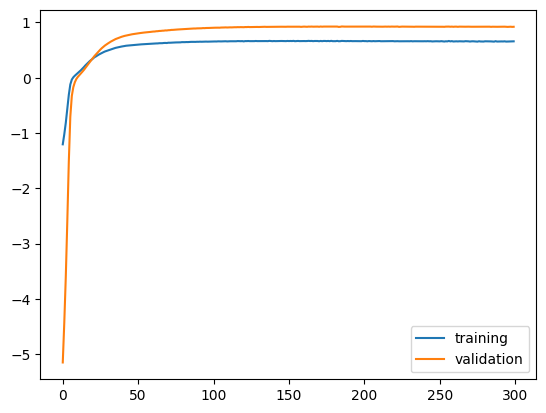

In [ ]:
scores = []
scores_val = []
net.train()
for epoch in tqdm(range(300)):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, batch in tqdm(enumerate(train_dataloader, 0)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / len(train_dataloader):.5f}')
    scores.append(eval_dataset(train_dataloader))
    scores_val.append(eval_dataset(test_dataloader))
    print('R2 score on train:', scores[-1])
    print('R2 score on val:', scores_val[-1])
print('Finished Training')
plt.plot(scores, label='training')
plt.plot(scores_val, label='validation')
plt.legend()

In [ ]:
net.eval()
pred = []
batch_size = 128
for i in tqdm(range(tensor_x.shape[0]//batch_size+1)):
    preds = net(tensor_x[i*batch_size:(i+1)*batch_size].to(device))
    pred.append(np.transpose(preds.detach().cpu().numpy(),
                             [0, 2, 1])*normalization)
pred = np.concatenate(pred, axis=0)
_, xrec = signal.istft((pred[:,:,0]+pred[:,:,1]*1j).T, fs)
xrec = data_noised - xrec[:data.size]
print(r2_score(data, data_noised))
print(r2_score(data, xrec[:data.size]))
print('Original')
display(Audio(data[fs*0:fs*15], rate=fs))
print('Noised')
display(Audio(data_noised[fs*0:fs*15], rate=fs))
print('Denoised')
display(Audio(xrec[fs*0:fs*15], rate=fs))

  0%|          | 0/9 [00:00<?, ?it/s]

0.6898789408941255
0.9183498436541779
Original


Noised


Denoised


Теперь на базе предоставленного кода используйте свою мелодию/песню и шум по варианту